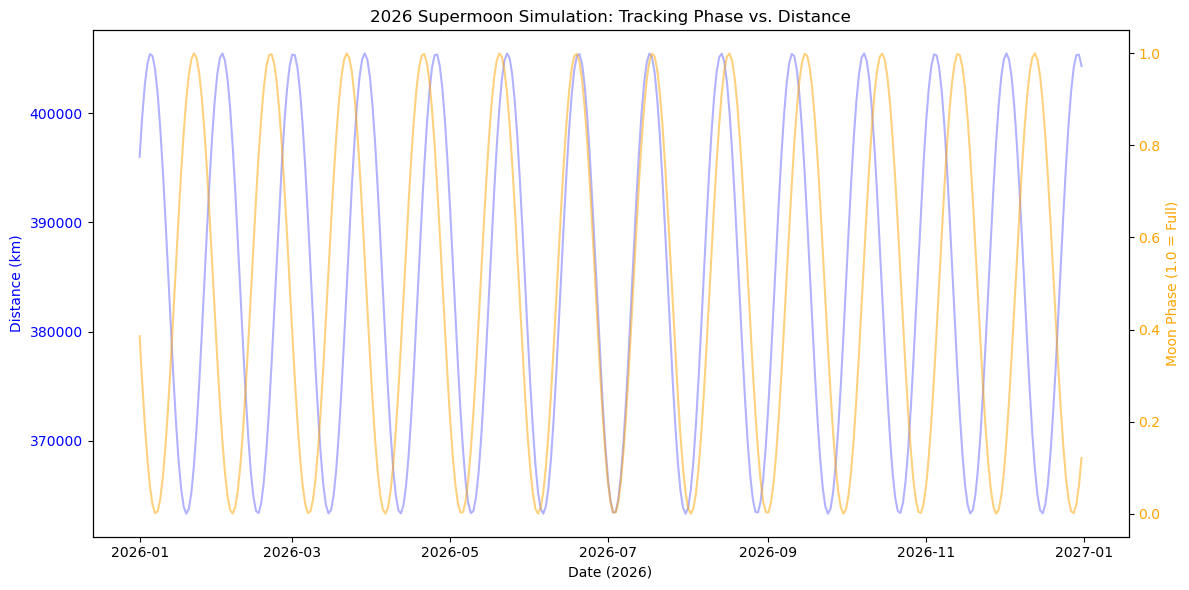

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

def simulate_supermoons(start_date, days_to_scan=365):
    # Constants (Averages)
    synodic_month = 29.53059  # Full moon to full moon
    anomalistic_month = 27.55455  # Perigee to perigee
    
    # Known reference: Full Moon & Perigee occurred near Nov 24, 2025
    ref_full_moon = datetime(2025, 11, 24)
    ref_perigee = datetime(2025, 11, 25)
    
    dates = [start_date + timedelta(days=i) for i in range(days_to_scan)]
    distances = []
    phases = [] # 1.0 = Full, 0.0 = New
    
    for d in dates:
        # Calculate Phase (Sine wave approximation)
        days_since_full = (d - ref_full_moon).total_seconds() / 86400
        phase = 0.5 * (1 + np.cos(2 * np.pi * days_since_full / synodic_month))
        phases.append(phase)
        
        # Calculate Distance (Sine wave between 363,300 and 405,500 km)
        days_since_perigee = (d - ref_perigee).total_seconds() / 86400
        dist = 384400 - 21100 * np.cos(2 * np.pi * days_since_perigee / anomalistic_month)
        distances.append(dist)
        
    return dates, np.array(distances), np.array(phases)

# Run simulation for 2026
current_date = datetime(2026, 1, 1)
dates, dists, phases = simulate_supermoons(current_date)

# Identification logic: Phase > 0.98 (Full) and Distance < 365,000 (Close)
supermoon_indices = np.where((phases > 0.99) & (dists < 365000))[0]

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date (2026)')
ax1.set_ylabel('Distance (km)', color='blue')
ax1.plot(dates, dists, color='blue', alpha=0.3, label='Lunar Distance')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Moon Phase (1.0 = Full)', color='orange')
ax2.plot(dates, phases, color='orange', alpha=0.5, label='Moon Phase')
ax2.tick_params(axis='y', labelcolor='orange')

# Mark Supermoons
for idx in supermoon_indices:
    ax1.plot(dates[idx], dists[idx], 'ro', markersize=10)
    ax1.annotate('SUPERMOON', (dates[idx], dists[idx]), textcoords="offset points", 
                 xytext=(0,10), ha='center', color='red', weight='bold')

plt.title("2026 Supermoon Simulation: Tracking Phase vs. Distance")
fig.tight_layout()
plt.show()